<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/standford.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Decend - example

In [30]:
def func(x):
  return 3*x**2 -5*x+5

In [31]:
func(100)

29505

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([105.    ,  96.4375,  88.25  ,  80.4375,  73.    ,  65.9375,
         59.25  ,  52.9375,  47.    ,  41.4375,  36.25  ,  31.4375,
         27.    ,  22.9375,  19.25  ,  15.9375,  13.    ,  10.4375,
          8.25  ,   6.4375,   5.    ,   3.9375,   3.25  ,   2.9375,
          3.    ,   3.4375,   4.25  ,   5.4375,   7.    ,   8.9375,
         11.25  ,  13.9375,  17.    ,  20.4375,  24.25  ,  28.4375,
         33.    ,  37.9375,  43.25  ,  48.9375]))

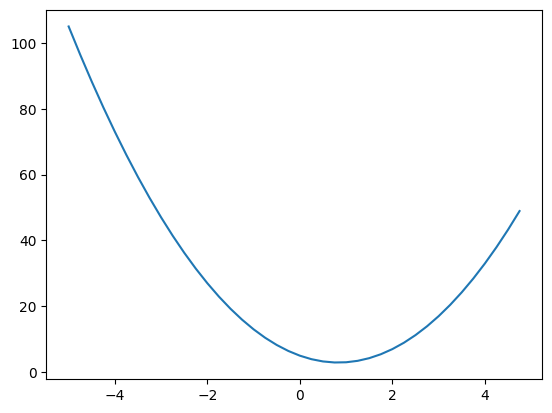

In [32]:
xs=np.arange(-5,5,0.25)
xs
ys = func(xs)
plt.plot(xs,ys)
xs ,ys

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([105.    ,  96.4375,  88.25  ,  80.4375,  73.    ,  65.9375,
         59.25  ,  52.9375,  47.    ,  41.4375,  36.25  ,  31.4375,
         27.    ,  22.9375,  19.25  ,  15.9375,  13.    ,  10.4375,
          8.25  ,   6.4375,   5.    ,   3.9375,   3.25  ,   2.9375,
          3.    ,   3.4375,   4.25  ,   5.4375,   7.    ,   8.9375,
         11.25  ,  13.9375,  17.    ,  20.4375,  24.25  ,  28.4375,
         33.    ,  37.9375,  43.25  ,  48.9375]),
 array([104.98250075,  96.42075075,  88.23400075,  80.42225075,
         72.98550075,  65.92375075,  59.23700075,  52.92525075,
         46.98850075,  41.42675075,  36.24000075,  31.42825075,
         26.99150075,  22.92

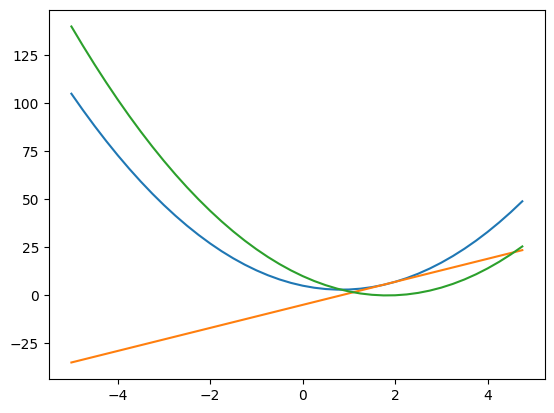

In [33]:
h = 0.0005
k = (func(xs+h) -func(xs))/h

dl = func(xs) - k
plt.plot(xs, func(xs+h))
plt.plot(xs, k)

plt.plot(xs, dl)

xs, func(xs),func(xs+h),k, dl

In [34]:
a=5
b=6
c=8
d = a*b+c
d

38

# Example of grdient - local and global

In [35]:
class Value:
  def __init__(self, val1, _child=(), _op='', label=''):
    self.data = val1
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_child)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(label={self.label}, data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def backward(self):
    # Topological sort to order the nodes
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    # Go backwards through the sorted list
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(131, label='a')
b = Value(151, label='b')
c = Value(161, label='c')

d = a*b; d.label = 'd'
e = d+c; e.label = 'e'
f = e*a; f.label = 'f'
L = f+c; L.label = 'L'
#(a*b+c)*a+c

# Corrected attribute access from .prev to ._prev
print(a.data, b.data, c.data, d.data, e.data, f.data, L.data)
print(a._prev, b._prev, c._prev, d._prev, e._prev, f._prev, L._prev)
print(a._op, b._op, c._op, d._op, e._op, f._op, L._op)
print(a.label, b.label, c.label, d.label, e.label, f.label, L.label)

131 151 161 19781 19942 2612402 2612563
set() set() set() {Value(label=a, data=131), Value(label=b, data=151)} {Value(label=c, data=161), Value(label=d, data=19781)} {Value(label=e, data=19942), Value(label=a, data=131)} {Value(label=f, data=2612402), Value(label=c, data=161)}
   * + * +
a b c d e f L


In [36]:
e._prev, d._prev, e._op, d._op
# d

({Value(label=c, data=161), Value(label=d, data=19781)},
 {Value(label=a, data=131), Value(label=b, data=151)},
 '+',
 '*')

In [37]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    label_str = f"{n.label} | data {n.data:.4f} | grad {n.grad:.4f}"
    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

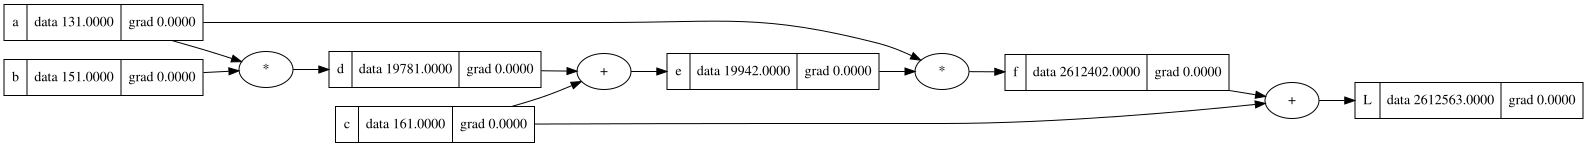

In [38]:
draw_dot(L)

### Why 'f' and 'd' both matter
Look at the graph below. Notice that `a` has two outgoing edges:
1. One goes to `d` (multiplied by `b`)
2. One goes to `f` (multiplied by `e`)

Because `a` is a direct input to both `d` and `f`, its total influence on `L` must account for both connections.

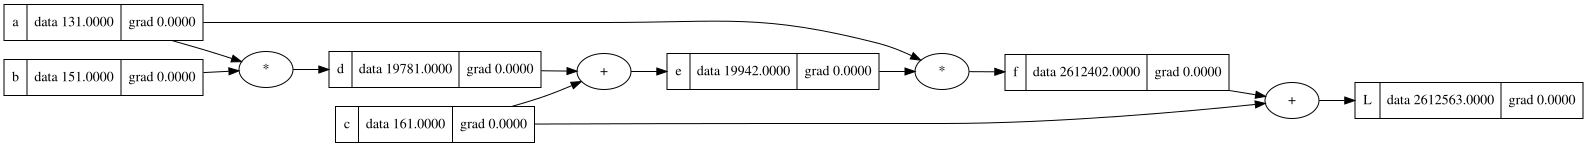

In [39]:
draw_dot(L)

In [40]:
def loc():
  h = 0.001

  # First run: normal values
  a = Value(131.0, label='a')
  b = Value(151.0, label='b')
  c = Value(161.0, label='c')
  d = a*b; d.label = 'd'
  e = d+c; e.label = 'e'
  f = e*a; f.label = 'f'
  L = f+c; L.label = 'L'
  L1 = f.data

  # Second run: nudge 'a' BEFORE calculating the dependent variables
  a = Value(131.0, label='a')
  b = Value(151.0, label='b')
  c = Value(161.0, label='c')

  a.data += h # Nudge input first

  d = a*b; d.label = 'd'
  # d.data += h # Nudge input first

  e = d+c; e.label = 'e'
  # e.data += h # Nudge input first

  f = e*a; f.label = 'f'
  # f.data += h # Nudge input first

  L = f+c; L.label = 'L'
  L2 = f.data

  return L1, L2, (L2-L1)/h

loc()

(2612402.0, 2612441.723151, 39723.1510002166)

In [41]:
f.grad = 1
c.grad = 132.00000021606684
a.grad=39723.1510002166 #dd/da = 151.00000000165892;df/da=39723.1510002166
b.grad=17161.000000312924
d.grad =131.00000005215406
e.grad=131.00000005215406

# if we know wvery node data, we can get a local grad, but we actually need global grad that is with respect to dl
# and that node, so we finally multiply all the local grad to get it


In [42]:
# Let's calculate the two separate components of a's gradient
# Expression: L = ((a * b + c) * a) + c

# 1. Gradient of a through the path of 'd'
# d = a * b -> dd/da = b
grad_a_path_1 = b.data

# 2. Gradient of a through the direct path to 'f'
# f = e * a -> df/da = e
grad_a_path_2 = e.data

print(f"Local grad from d: {grad_a_path_1}")
print(f"Local grad from f: {grad_a_path_2}")
print(f"Total sensitivity: {grad_a_path_1 + grad_a_path_2}")

Local grad from d: 151
Local grad from f: 19942
Total sensitivity: 20093


### Verifying the Total Gradient for 'a'
Based on the chain rule, we will manually apply the gradients from the output `L` backwards.
Remember: `L = f + c`, so `dL/df = 1` and `dL/dc = 1`.

Manual Backprop a.grad: 39723.0
Earlier Nudge Test result: ~39723


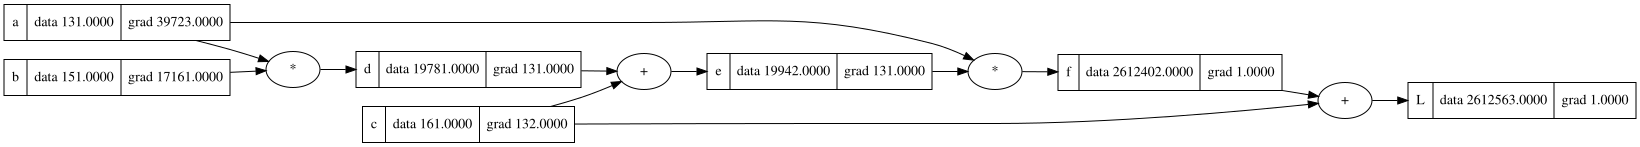

In [43]:
# 1. Initialize top-level gradient
L.grad = 1.0

# 2. Backprop through L = f + c
f.grad = 1.0 * L.grad
c.grad = 1.0 * L.grad

# 3. Backprop through f = e * a
# df/de = a, df/da = e
e.grad = a.data * f.grad
# Note: we use += for 'a' because it will receive gradients from elsewhere too!
a.grad = e.data * f.grad

# 4. Backprop through e = d + c
# de/dd = 1, de/dc = 1
d.grad = 1.0 * e.grad
c.grad += 1.0 * e.grad # c also appears twice!

# 5. Backprop through d = a * b
# dd/da = b, dd/db = a
a.grad += b.data * d.grad # ACCUMULATING gradient from the second path
b.grad = a.data * d.grad

print(f"Manual Backprop a.grad: {a.grad}")
print(f"Earlier Nudge Test result: ~39723")
draw_dot(L)

### The Multivariate Chain Rule
If a variable (like `a`) flows into multiple paths in the graph, its total gradient is the **sum** of the gradients from each path.

$$\frac{\partial L}{\partial a} = \sum_{i} \frac{\partial L}{\partial path_i} \cdot \frac{\partial path_i}{\partial a}$$

In our case:
`a.grad = (dL/df * df/da) + (dL/df * df/de * de/dd * dd/da)`

Automated a.grad: 39723.0


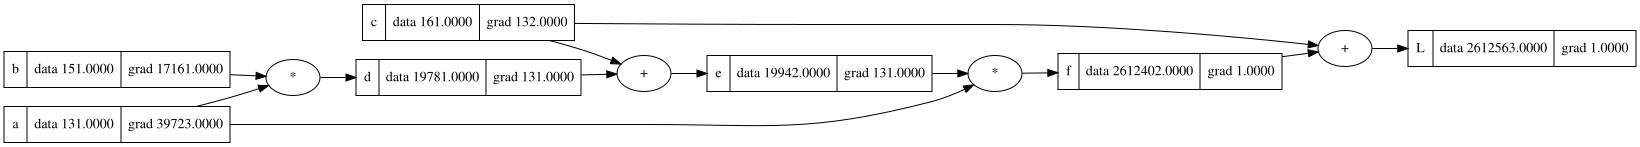

In [44]:
# 1. Re-initialize the graph
a = Value(131.0, label='a')
b = Value(151.0, label='b')
c = Value(161.0, label='c')
d = a * b; d.label = 'd'
e = d + c; e.label = 'e'
f = e * a; f.label = 'f'
L = f + c; L.label = 'L'

# 2. Run the automated backpropagation
L.backward()

# 3. Verify results
print(f"Automated a.grad: {a.grad}")
draw_dot(L)

### Mathematical Verification of `a.grad` and `c.grad`

Let's use the local derivatives you listed and apply the chain rule properly by multiplying by the upstream gradients:

**For c:**
- Path 1: $L \to c \implies \frac{\partial L}{\partial c} = 1$
- Path 2: $L \to f \to e \to c \implies \frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial e} \cdot \frac{\partial e}{\partial c} = 1 \cdot a \cdot 1 = a$
- Total $\frac{\partial L}{\partial c} = 1 + a$

**For a:**
- Path 1 (Direct to f): $\frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial a} = 1 \cdot e$
- Path 2 (Through d): $\frac{\partial L}{\partial f} \cdot \frac{\partial f}{\partial e} \cdot \frac{\partial e}{\partial dd} \cdot \frac{\partial d}{\partial a} = 1 \cdot a \cdot 1 \cdot b$
- Total $\frac{\partial L}{\partial a} = e + (a \cdot b)$

In [45]:
# Using the values from the previous cell
a_val = 131.0
b_val = 151.0
c_val = 161.0
d_val = a_val * b_val
e_val = d_val + c_val

# Calculate gradients based on the multivariate chain rule derivation above
grad_c = 1 + a_val
grad_a = e_val + (a_val * b_val)

print(f"Calculated c.grad: {grad_c}")
print(f"Calculated a.grad: {grad_a}")
print(f"Matches automated backprop? {grad_a == a.grad}")

Calculated c.grad: 132.0
Calculated a.grad: 39723.0
Matches automated backprop? True


### Inspecting Internal State

Each `Value` object maintains its own internal state. When we perform an operation like `d = a * b`, a **new** `Value` object is created for `d`, which holds references to its parents (`a` and `b`) in its `_prev` set.

When we call `backward()`, it finds every unique `Value` object and updates its specific `grad` attribute.

In [46]:
# Let's look at the internal dictionary of our variables
print("Internal state of 'a':")
display(a.__dict__)

print("\nInternal state of 'd' (the product of a and b):")
display(d.__dict__)

# Note how 'd' stores 'a' and 'b' in '_prev' to remember the graph structure

Internal state of 'a':


{'data': 131.0,
 'grad': 39723.0,
 '_backward': <function __main__.Value.__init__.<locals>.<lambda>()>,
 '_prev': set(),
 '_op': '',
 'label': 'a'}


Internal state of 'd' (the product of a and b):


{'data': 19781.0,
 'grad': 131.0,
 '_backward': <function __main__.Value.__mul__.<locals>._backward()>,
 '_prev': {Value(label=a, data=131.0), Value(label=b, data=151.0)},
 '_op': '*',
 'label': 'd'}

### Local vs. Global Gradients

| Term | Where is it? | What is it? |
| :--- | :--- | :--- |
| **Local Gradient** | Inside `_backward()` | The derivative of an output with respect to its immediate input (e.g., in `a*b`, it's just `b`). |
| **Global Gradient** | `self.grad` | The derivative of the final result `L` with respect to this node, calculated by multiplying the local grad by the upstream grad. |

In [47]:
# To prove it, notice that even if 'd' is very large (19781),
# its grad (131) is relative to 'L', not relative to its inputs.

print(f"Value of d: {d.data}")
print(f"Global Gradient of d (dL/dd): {d.grad}")
print("Note that d.grad is exactly 'a', because L = (d+c)*a + c, and dL/dd = a.")

Value of d: 19781.0
Global Gradient of d (dL/dd): 131.0
Note that d.grad is exactly 'a', because L = (d+c)*a + c, and dL/dd = a.


# tanh

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]


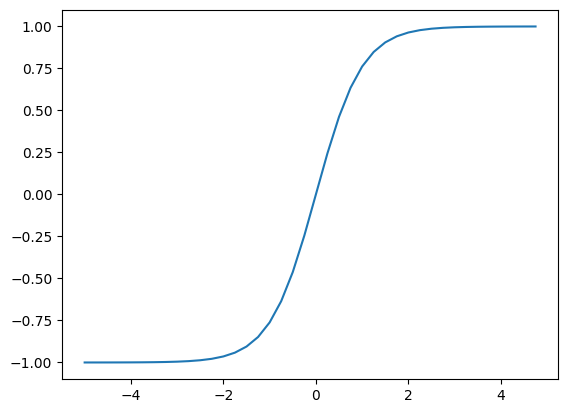

In [48]:
plt.plot(np.arange(-5,5,0.25), np.tanh(np.arange(-5,5,0.25)));plt.plot()
print(np.arange(-5,5,0.25))

In [54]:
class neuron:
  def __init__(self, w_data, _track=(), _op='', label=''):
    self.wt_data = w_data
    self.label = label
    self.track = set(_track)
    self._op = _op
    self.grad = 0.0

  def __repr__(self):
    return f"Neuron(label={self.label}, weight={self.wt_data})"

  def __mul__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    return neuron(self.wt_data * others.wt_data, (self, others), '*')

  def __add__(self, others):
    others = others if isinstance(others, neuron) else neuron(others)
    return neuron(self.wt_data + others.wt_data, (self, others), '+')

  def tanh(self):
    x = self.wt_data
    t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
    return neuron(t, (self, ), 'tanh', label='tanh')

w1 = neuron(1.0, label='w1')
x1 = neuron(2.0, label='x1')
b = neuron(3.0, label='b')
w2 = neuron(4.0, label='w2')
x2 = neuron(5.0, label='x2')
b2 = neuron(6.0, label='b2')

# Expressions
w1x1 = w1*x1; w1x1.label = 'w1*x1'
w2x2 = w2*x2; w2x2.label = 'w2*x2'
w1x1w2x2 = w1x1+w2x2; w1x1w2x2.label = 'w1x1+w2x2'
w1x1w2x2b = w1x1w2x2+b; w1x1w2x2b.label = 'w1x1+w2x2+b'

In [55]:
from graphviz import Digraph

def neu_trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v.track:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot_n(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = neu_trace(root)
  for n in nodes:
    uid = str(id(n))
    label_str = f"{n.label} | data {n.wt_data:.4f} | grad {n.grad:.4f}"
    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

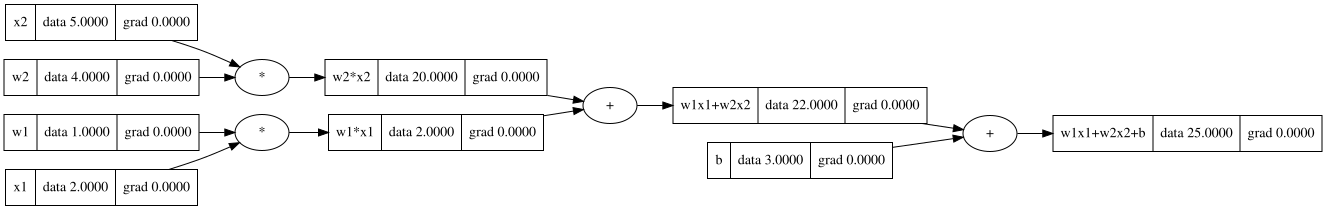

In [57]:
draw_dot_n(w1x1w2x2b)

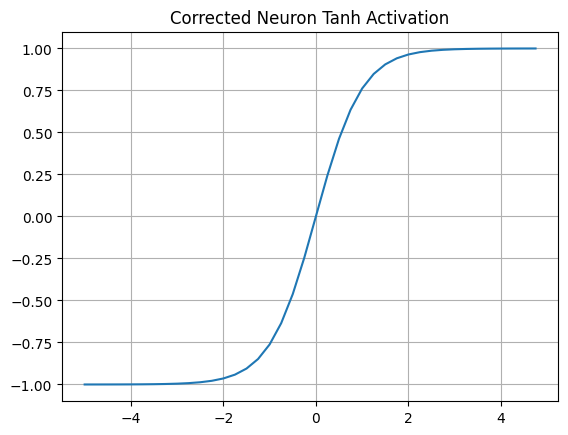

In [58]:
a = np.arange(-5, 5, 0.25)
results = np.zeros_like(a)

for idx, i in enumerate(a):
    n = neuron(i)
    res = n.tanh()
    results[idx] = res.wt_data

plt.plot(a, results)
plt.title("Corrected Neuron Tanh Activation")
plt.grid(True)
plt.show()

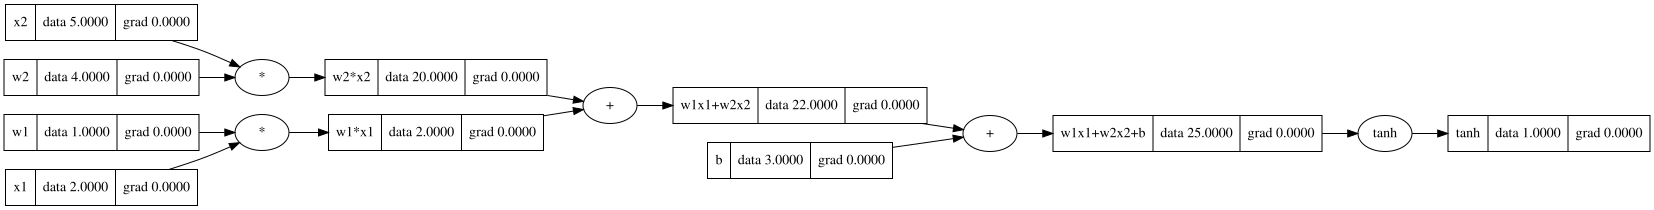

In [60]:
tan_h = w1x1w2x2b.tanh(); #tan_h.label = 'tanh'
draw_dot_n(tan_h)